In [1]:
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orig_rna_soybean = sc.read_h5ad(
    r"C:\Users\mikep\git\Soybean_Single_Cell_drought_heat\Data\anndata_export\adata_rna.h5ad"
)

orig_rna_soybean.var

,highly_variable,in_integrated
Glyma.01G161700.Wm82.a4.v1,False,False
Glyma.04G126700.Wm82.a4.v1,True,False
Glyma.20G213700.Wm82.a4.v1,True,False
Glyma.03G158766.Wm82.a4.v1,False,False
Glyma.03G058100.Wm82.a4.v1,False,False
...,...,...
Glyma.03G197800.Wm82.a4.v1,False,False
Glyma.01G035600.Wm82.a4.v1,False,False
Glyma.07G008100.Wm82.a4.v1,True,False
Glyma.15G219800.Wm82.a4.v1,False,False


In [3]:
orig_rna_soybean.var["gene_name"] = (
    orig_rna_soybean.var.index.str.split(".").str[0]
    + "."
    + orig_rna_soybean.var.index.str.split(".").str[1].str.lower()
)
orig_rna_soybean.var

,highly_variable,in_integrated,gene_name
Glyma.01G161700.Wm82.a4.v1,False,False,Glyma.01g161700
Glyma.04G126700.Wm82.a4.v1,True,False,Glyma.04g126700
Glyma.20G213700.Wm82.a4.v1,True,False,Glyma.20g213700
Glyma.03G158766.Wm82.a4.v1,False,False,Glyma.03g158766
Glyma.03G058100.Wm82.a4.v1,False,False,Glyma.03g058100
...,...,...,...
Glyma.03G197800.Wm82.a4.v1,False,False,Glyma.03g197800
Glyma.01G035600.Wm82.a4.v1,False,False,Glyma.01g035600
Glyma.07G008100.Wm82.a4.v1,True,False,Glyma.07g008100
Glyma.15G219800.Wm82.a4.v1,False,False,Glyma.15g219800


In [4]:
gene_conversion_table = pd.read_csv(
    r"C:\Users\mikep\git\Soybean_Single_Cell_drought_heat\Referenced_data\Wm82.a4.v1_to_Correspondence_Full.csv"
)
gene_conversion_table_2 = gene_conversion_table.loc[
    gene_conversion_table["Assembly"] == "Glyma2.0"
]
gene_conversion_table_2

,Wm82.a4.v1 Gene,Corresponding Gene,Assembly
1,Glyma.01g000100,Glyma.01g000100,Glyma2.0
3,Glyma.01g000400,Glyma.01g000400,Glyma2.0
5,Glyma.01g000600,Glyma.01g000600,Glyma2.0
7,Glyma.01g001000,Glyma.01g001000,Glyma2.0
9,Glyma.01g001100,Glyma.01g001100,Glyma2.0
...,...,...,...
84445,Glyma.u044100,Glyma.u044100,Glyma2.0
84447,Glyma.u044700,Glyma.u044700,Glyma2.0
84449,Glyma.u044800,Glyma.u044800,Glyma2.0
84451,Glyma.u045000,Glyma.u045000,Glyma2.0


In [5]:
gene_conversion_table

,Wm82.a4.v1 Gene,Corresponding Gene,Assembly
0,Glyma.01g000100,Glyma01g00210,Glyma 1.1
1,Glyma.01g000100,Glyma.01g000100,Glyma2.0
2,Glyma.01g000400,Glyma01g00300,Glyma 1.1
3,Glyma.01g000400,Glyma.01g000400,Glyma2.0
4,Glyma.01g000600,Glyma01g00321,Glyma 1.1
...,...,...,...
84449,Glyma.u044800,Glyma.u044800,Glyma2.0
84450,Glyma.u045000,Glyma0101s00230,Glyma 1.1
84451,Glyma.u045000,Glyma.u045000,Glyma2.0
84452,Glyma.u045200,Glyma0101s00210,Glyma 1.1


In [6]:
gene_conversion_table_2.loc[
    ~(
        gene_conversion_table_2["Wm82.a4.v1 Gene"]
        == gene_conversion_table_2["Corresponding Gene"]
    )
]

,Wm82.a4.v1 Gene,Corresponding Gene,Assembly
1312,Glyma.01g095166,Glyma01g11755,Glyma2.0
1314,Glyma.01g095232,Glyma.06G219900,Glyma2.0
1608,Glyma.01g121209,Glyma01g29930,Glyma2.0
1610,Glyma.01g121218,Glyma01g29950,Glyma2.0
1612,Glyma.01g121245,Glyma01g30000,Glyma2.0
...,...,...,...
84412,Glyma.u032305,Glyma03g05661,Glyma2.0
84414,Glyma.u032405,Glyma.03G047000,Glyma2.0
84418,Glyma.u032605,Glyma03g05680,Glyma2.0
84422,Glyma.u032805,Glyma.03G047300,Glyma2.0


In [7]:
drought_de_genes = pd.read_csv(
    r"C:\Users\mikep\git\Soybean_Single_Cell_drought_heat\Referenced_data\Wang_DE_gene_lists\only_drought_24h_DE.csv"
)
drought_de_genes

,GeneID,Means-CK,Means-D_24,log2Ratio (D_24/CK),Up-Down-Regulation (D_24/CK),Probability
0,GLYMA12G01770,6.326667,31.870000,2.332682,Up,0.828554
1,GLYMA16G04190,117.460000,865.586667,2.881509,Up,0.887451
2,GLYMA07G07360,1.010000,13.520000,3.742668,Up,0.863054
3,GLYMA09G00670,33.533333,142.660000,2.088913,Up,0.831820
4,GLYMA10G38710,3.323333,20.033333,2.591700,Up,0.829268
...,...,...,...,...,...,...
816,GLYMA17G37900,66.090000,5.733333,-3.526986,Down,0.905868
817,GLYMA14G03580,53.776667,3.503333,-3.940180,Down,0.918887
818,GLYMA11G10080,83.640000,3.433333,-4.606511,Down,0.947066
819,GLYMA20G27580,18.503333,3.523333,-2.392772,Down,0.810997


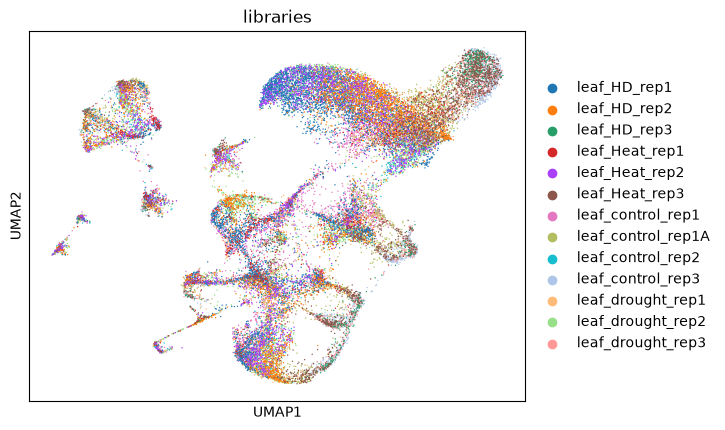

In [8]:
sc.pl.umap(orig_rna_soybean, color=["libraries"], wspace=0.4)

## Convert the v4 gene IDs to the DE-list nomenclature

The Wang DE lists use IDs like `GLYMA11G21190`. Matching after stripping periods and
case (so formatting differences can't hide a match), against the drought+heat list
(1906 genes):

| conversion source | DE genes matched |
|---|---|
| `Glyma2.0` corresponding gene | 7 / 1906 |
| `Glyma 1.1` corresponding gene | 1651 / 1906 |

The Wang IDs are **Glyma 1.1 (Wm82.a1.v1)**, not Glyma2.0. This is not a punctuation
difference: Glyma2.0 gene numbers are 6 digits (`Glyma.01g000100`) while the Wang IDs
are 5 (`Glyma11g21190`), matching the Glyma 1.1 column. For example `GLYMA11G21190`
maps to a4 gene `Glyma.11g151800`, whose Glyma2.0 name is `Glyma.11g151800` — unchanged
from a4, and nothing like the Wang ID.

A handful of IDs per list also carry a transcript suffix (`GLYMA19G01050.13`), which
`normalise_gene_id` strips; that recovers 3–5 extra genes per list.

Both conversions are added below (`gene_v2` and `gene_v1_1`), but the DE matching uses
`gene_v1_1` because that is the one that actually joins.

In [9]:
# --- add the converted gene IDs to .var ---------------------------------------
def normalise_gene_id(series):
    """Upper-case, drop a trailing transcript suffix (".13"), and drop periods, so
    IDs from different sources can be joined."""
    return (
        series.str.upper()
        .str.replace(r"\.\d+$", "", regex=True)
        .str.replace(".", "", regex=False)
    )


for assembly, column in [("Glyma2.0", "gene_v2"), ("Glyma 1.1", "gene_v1_1")]:
    subset = gene_conversion_table.loc[gene_conversion_table["Assembly"] == assembly]
    orig_rna_soybean.var[column] = orig_rna_soybean.var["gene_name"].map(
        dict(zip(subset["Wm82.a4.v1 Gene"], subset["Corresponding Gene"]))
    )

# normalised keys used for the joins
orig_rna_soybean.var["gene_v2_norm"] = normalise_gene_id(
    orig_rna_soybean.var["gene_v2"]
)
orig_rna_soybean.var["gene_v1_1_norm"] = normalise_gene_id(
    orig_rna_soybean.var["gene_v1_1"]
)
drought_de_genes["GeneID_norm"] = normalise_gene_id(drought_de_genes["GeneID"])

for column in ["gene_v2_norm", "gene_v1_1_norm"]:
    n_found = (
        drought_de_genes["GeneID_norm"]
        .isin(set(orig_rna_soybean.var[column].dropna()))
        .sum()
    )
    print(
        f"{column:15s}: {n_found:5d} / {len(drought_de_genes)} DE genes found in the anndata"
    )

orig_rna_soybean.var.head()

gene_v2_norm   :     0 / 821 DE genes found in the anndata
gene_v1_1_norm :   612 / 821 DE genes found in the anndata


,highly_variable,in_integrated,gene_name,gene_v2,gene_v1_1,gene_v2_norm,gene_v1_1_norm
Glyma.01G161700.Wm82.a4.v1,False,False,Glyma.01g161700,Glyma.01g161700,Glyma01g36638,GLYMA01G161700,GLYMA01G36638
Glyma.04G126700.Wm82.a4.v1,True,False,Glyma.04g126700,Glyma.04g126700,Glyma04g15361,GLYMA04G126700,GLYMA04G15361
Glyma.20G213700.Wm82.a4.v1,True,False,Glyma.20g213700,Glyma.20g213700,Glyma20g35630,GLYMA20G213700,GLYMA20G35630
Glyma.03G158766.Wm82.a4.v1,False,False,Glyma.03g158766,NaN,NaN,NaN,NaN
Glyma.03G058100.Wm82.a4.v1,False,False,Glyma.03g058100,Glyma.03g058100,Glyma03g07890,GLYMA03G058100,GLYMA03G07890


## Top 100 up-regulated genes

The selection is wrapped in `select_top_up_genes()` so the same logic can be reused for
each of the three Wang DE lists further down. The per-contrast column names (`D_24`,
`DH_24`, `H_24`) are looked up from each table rather than hard-coded, so swapping the
file loaded into `drought_de_genes` needs no other change.

Two knobs control the selection:

* **`CONTROL_REF_LIBRARIES`** — the control libraries used as the baseline. All four
  control libraries (including `leaf_control_rep1A`) are currently in the reference.
  Drop `rep1A` from the list to use only the three numbered reps, in which case its
  cells get scored like any other non-reference cell and act as a null in the heatmap.
* **`MIN_REF_DETECT_FRAC`** — the detection floor, currently 5%. Some filter is
  necessary: ranking the up-regulated genes purely on `log2Ratio` selects the genes
  whose bulk `Means-CK` is essentially zero, and those are also undetected in the
  control single cells, so their control sd is 0 and the z-score is undefined. With no
  floor at all, 77 of the 100 rows came out empty on the drought+heat list. Raising the
  floor trades fold-change magnitude for genes that are reliably measured in single
  cells.

In [25]:
# --- pick the top up-regulated genes ------------------------------------------
import scipy.sparse as sp

MATCH_COLUMN = "gene_v1_1_norm"  # the var column that actually joins to the Wang IDs
N_TOP_GENES = 50
MIN_REF_DETECT_FRAC = 0.01  # gene must be detected in >= 5% of the reference cells
CONTROL_REF_LIBRARIES = [
    "leaf_control_rep1",
    "leaf_control_rep2",
    "leaf_control_rep3",
    "leaf_control_rep1A",
]

reference_mask = orig_rna_soybean.obs["libraries"].isin(CONTROL_REF_LIBRARIES).values
print(f"reference cells: {reference_mask.sum()} from {CONTROL_REF_LIBRARIES}")

v4_lookup = (
    orig_rna_soybean.var.loc[orig_rna_soybean.var[MATCH_COLUMN].notna(), [MATCH_COLUMN]]
    .reset_index(names="gene_v4")
    .drop_duplicates(subset=MATCH_COLUMN, keep="first")
)


def dense_expression(adata, genes):
    """Expression matrix (cells x genes) for `genes`, as a dense array."""
    X = adata[:, genes].X
    return np.asarray(X.todense()) if sp.issparse(X) else np.asarray(X)


def de_contrast_columns(de_table):
    """Each Wang table names its columns after its own contrast (D_24, DH_24, H_24),
    so find them rather than hard-coding one table's names."""
    ratio_column = next(c for c in de_table.columns if c.startswith("log2Ratio"))
    direction_column = next(
        c for c in de_table.columns if c.startswith("Up-Down-Regulation")
    )
    treated_mean_column = next(
        c for c in de_table.columns if c.startswith("Means-") and c != "Means-CK"
    )
    return ratio_column, direction_column, treated_mean_column


def select_top_up_genes(
    de_table, n_top=N_TOP_GENES, min_detect_frac=MIN_REF_DETECT_FRAC
):
    """Top `n_top` up-regulated genes of a Wang DE table that are usable in this data."""
    ratio_column, direction_column, _ = de_contrast_columns(de_table)
    de_table = de_table.copy()
    de_table["GeneID_norm"] = normalise_gene_id(de_table["GeneID"])

    up_genes = (
        de_table.loc[de_table[direction_column] == "Up"]
        .merge(v4_lookup, left_on="GeneID_norm", right_on=MATCH_COLUMN, how="inner")
        .sort_values(ratio_column, ascending=False)
        # a few genes appear as several transcripts (".10", ".12", ".13") and collapse
        # to one ID once normalised; keep the strongest row per gene
        .drop_duplicates(subset="gene_v4", keep="first")
    )
    print(f"up-regulated DE genes present in the anndata: {len(up_genes)}")

    X_up = dense_expression(orig_rna_soybean, up_genes["gene_v4"].tolist())
    up_genes["ref_detect_frac"] = (X_up[reference_mask] > 0).mean(axis=0)
    up_genes["ref_sd"] = X_up[reference_mask].std(axis=0, ddof=1)

    # Genes never seen in the control cells have sd == 0, so their z-score is undefined.
    # Ranking on log2Ratio alone puts exactly those genes first (they are the ones with
    # Means-CK ~ 0 in the bulk data), which would leave most rows empty, so require
    # some detection in the reference before ranking.
    detected = (up_genes["ref_detect_frac"] >= min_detect_frac) & (
        up_genes["ref_sd"] > 0
    )
    top_genes = up_genes.loc[detected].head(n_top).reset_index(drop=True)
    print(
        f"{detected.sum()} of those are detected in >= {min_detect_frac:.0%} of the "
        f"reference cells; keeping the top {len(top_genes)} by log2Ratio"
    )
    return top_genes


top_up_genes = select_top_up_genes(drought_de_genes)

ratio_column, _, treated_mean_column = de_contrast_columns(drought_de_genes)
top_up_genes[
    [
        "GeneID",
        "gene_v4",
        "Means-CK",
        treated_mean_column,
        ratio_column,
        "ref_detect_frac",
    ]
].head(10)

reference cells: 9698 from ['leaf_control_rep1', 'leaf_control_rep2', 'leaf_control_rep3', 'leaf_control_rep1A']
up-regulated DE genes present in the anndata: 368
233 of those are detected in >= 1% of the reference cells; keeping the top 50 by log2Ratio


,GeneID,gene_v4,Means-CK,Means-D_24,log2Ratio (D_24/CK),ref_detect_frac
0,GLYMA19G01050.13,Glyma.19G007700.Wm82.a4.v1,0.010000,142.936667,13.803088,0.576717
1,GLYMA17G32731,Glyma.17G214600.Wm82.a4.v1,0.010000,36.586667,11.837102,0.107651
2,GLYMA15G39472,Glyma.15G246100.Wm82.a4.v1,0.010000,17.160000,10.744834,0.496185
3,GLYMA16G14385,Glyma.16G094000.Wm82.a4.v1,0.010000,9.150000,9.837628,0.011858
4,GLYMA07G19335,Glyma.07G157000.Wm82.a4.v1,0.010000,5.760000,9.169925,0.027738
5,GLYMA04G05500,Glyma.04G052000.Wm82.a4.v1,0.153333,28.696667,7.548068,0.161477
6,GLYMA03G40880.12,Glyma.03G248600.Wm82.a4.v1,0.046667,4.360000,6.545792,0.271499
7,GLYMA14G32430,Glyma.14G162100.Wm82.a4.v1,0.516667,47.260000,6.515242,0.029181
8,GLYMA12G32230,Glyma.12G196200.Wm82.a4.v1,0.410000,35.473333,6.434967,0.027119
9,GLYMA19G31674,Glyma.19G135600.Wm82.a4.v1,0.073333,5.436667,6.212109,0.017426


## Z-score every cell against the control reference

For each of the 100 genes the mean and sd are taken **only from the reference control
cells**, and every cell in the object (including the control cells themselves) is then
expressed as `(x - control_mean) / control_sd`. The 100 per-gene z-scores are written
to `.obs` as `zscore_<v4 gene id>`, plus a `drought_up100_zscore` column holding the
mean across the 100 genes as a single per-cell module score.

In [26]:
# --- per-cell z-scores against the control reference --------------------------
# one-off cleanup of the columns written by the earlier, un-prefixed version of this cell
orig_rna_soybean.obs = orig_rna_soybean.obs.drop(
    columns=[c for c in orig_rna_soybean.obs.columns if c.startswith("zscore_Glyma")]
    + ["drought_up100_zscore"],
    errors="ignore",
)


def add_module_zscores(top_genes, label):
    """Z-score every cell against the reference cells, for each gene in `top_genes`.

    Writes `zscore_<label>_<v4 gene id>` columns to .obs plus a
    `<label>_up<n>_zscore` summary column, and returns their names.
    """
    genes = top_genes["gene_v4"].tolist()
    X_top = dense_expression(orig_rna_soybean, genes)

    # mean / sd come from the reference cells only, then every cell is scored against them
    reference_mean = X_top[reference_mask].mean(axis=0)
    reference_sd = X_top[reference_mask].std(axis=0, ddof=1)
    z_scores = (X_top - reference_mean) / reference_sd

    gene_columns = [f"zscore_{label}_{gene}" for gene in genes]
    summary_column = f"{label}_up{len(genes)}_zscore"
    orig_rna_soybean.obs = orig_rna_soybean.obs.drop(
        columns=gene_columns + [summary_column], errors="ignore"
    )  # so the cell can be re-run cleanly
    orig_rna_soybean.obs = pd.concat(
        [
            orig_rna_soybean.obs,
            pd.DataFrame(
                z_scores, index=orig_rna_soybean.obs_names, columns=gene_columns
            ),
        ],
        axis=1,
    )
    # summary score across the genes, handy for UMAP colouring
    orig_rna_soybean.obs[summary_column] = z_scores.mean(axis=1)

    print(f"added {len(gene_columns)} z-score columns + {summary_column}")
    return gene_columns, summary_column


zscore_columns, summary_column = add_module_zscores(top_up_genes, "drought")
orig_rna_soybean.obs.groupby("treatment", observed=True)[summary_column].agg(
    ["mean", "median", "count"]
)

added 50 z-score columns + drought_up50_zscore


,mean,median,count
treatment,,,
Control,-8.527633e-08,-0.025791,9698
Drought,1.871958e-01,0.139619,5325
HD,6.220263e-01,0.598845,9931
Heat,1.034765e-01,0.071519,5513


## Heatmap of the z-scores

Rows are the 100 genes (labelled with the Wang IDs), columns are every
`cell type | library` combination. Each square is the mean z-score of the cells in
that combination, i.e. how far that group sits from the control reference in units
of control-cell standard deviations.

kept 103 of 112 cell type x library groups (>= 10 cells)


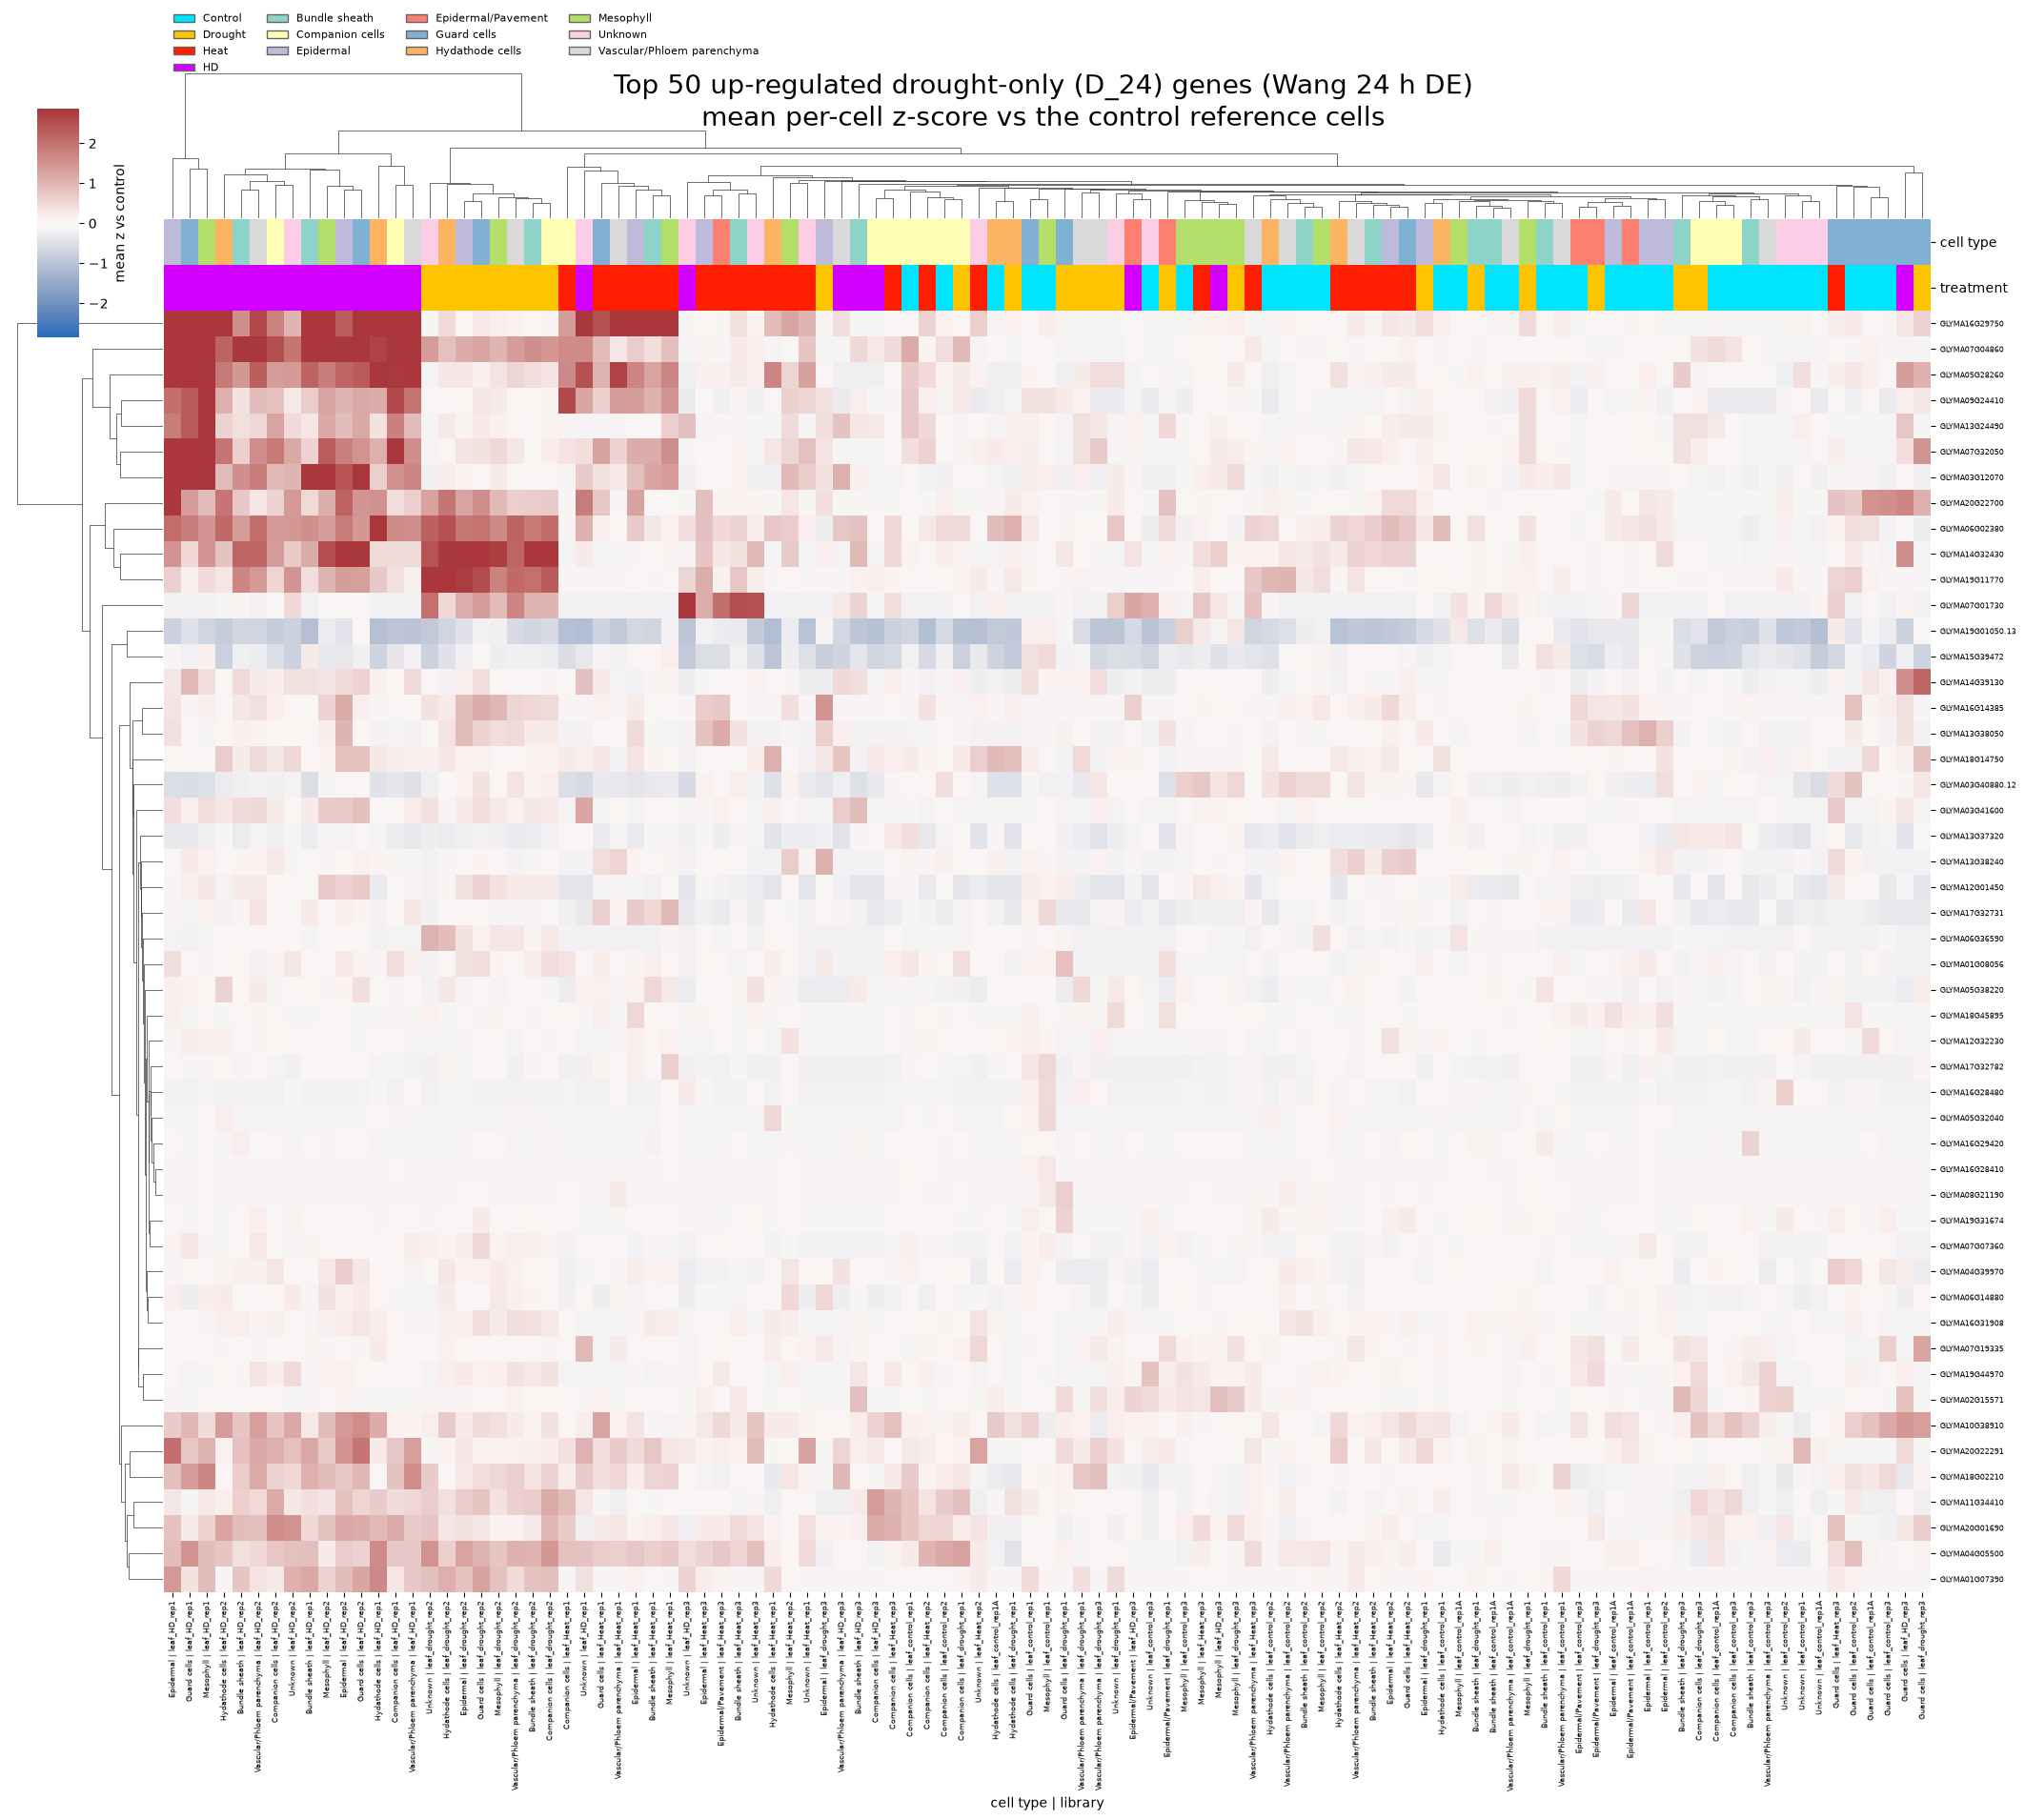

In [27]:
# --- clustermap: genes (rows) x cell type | library (columns) -----------------
from matplotlib.patches import Patch

MIN_CELLS_PER_GROUP = (
    10  # skip cell type x library combos with too few cells to average
)

# Treatment is the variable of interest, so it gets four bright, fully saturated
# colours; the cell types get a softer qualitative palette. The two sets share no
# colours, so the two bars can't be confused with each other.
TREATMENT_PALETTE = {
    "Control": "#00E5FF",  # electric cyan
    "Drought": "#FFC400",  # amber
    "Heat": "#FF1E00",  # scarlet
    "HD": "#D400FF",  # magenta
}


def plot_module_clustermap(
    top_genes, gene_columns, contrast_label, min_cells=MIN_CELLS_PER_GROUP
):
    """Clustermap of mean z-score per gene x (cell type | library) group."""
    groups = orig_rna_soybean.obs.groupby(["celltype_call", "libraries"], observed=True)
    group_sizes = groups.size()
    group_means = (
        groups[gene_columns].mean().loc[group_sizes[group_sizes >= min_cells].index]
    )
    print(
        f"kept {len(group_means)} of {len(group_sizes)} cell type x library groups "
        f"(>= {min_cells} cells)"
    )

    heatmap_data = group_means.T
    heatmap_data.index = top_genes["GeneID"].values  # label rows with the Wang DE IDs
    heatmap_data.columns = [f"{ct} | {lib}" for ct, lib in group_means.index]

    # colour bars so the treatment / cell type of each column is readable at a glance
    library_treatment = (
        orig_rna_soybean.obs.drop_duplicates("libraries")
        .set_index("libraries")["treatment"]
        .to_dict()
    )
    column_celltypes = [c.split(" | ")[0] for c in heatmap_data.columns]
    column_libraries = [c.split(" | ")[1] for c in heatmap_data.columns]
    celltype_palette = dict(
        zip(
            sorted(set(column_celltypes)),
            sns.color_palette("Set3", len(set(column_celltypes))),
        )
    )
    col_colors = pd.DataFrame(
        {
            "cell type": [celltype_palette[c] for c in column_celltypes],
            "treatment": [
                TREATMENT_PALETTE[library_treatment[l]] for l in column_libraries
            ],
        },
        index=heatmap_data.columns,
    )

    # clip the colour scale at the 99th percentile so a few extreme groups don't wash it out
    colour_limit = np.nanpercentile(np.abs(heatmap_data.values), 99)

    cg = sns.clustermap(
        heatmap_data,
        cmap="vlag",
        center=0,
        vmin=-colour_limit,
        vmax=colour_limit,
        col_colors=col_colors,
        figsize=(22, 20),
        xticklabels=True,
        yticklabels=True,
        dendrogram_ratio=(0.08, 0.10),
        cbar_pos=(0.02, 0.85, 0.02, 0.12),
        cbar_kws={"label": "mean z vs control"},
    )
    cg.ax_heatmap.set_xticklabels(
        cg.ax_heatmap.get_xticklabels(), rotation=90, fontsize=6
    )
    cg.ax_heatmap.set_yticklabels(
        cg.ax_heatmap.get_yticklabels(), rotation=0, fontsize=6
    )
    cg.ax_heatmap.set_xlabel("cell type | library")
    cg.ax_heatmap.set_ylabel("")

    legend_handles = [
        Patch(facecolor=TREATMENT_PALETTE[t], edgecolor="0.4", label=t)
        for t in ["Control", "Drought", "Heat", "HD"]
    ] + [
        Patch(facecolor=celltype_palette[c], edgecolor="0.4", label=c)
        for c in sorted(set(column_celltypes))
    ]
    cg.ax_col_dendrogram.legend(
        handles=legend_handles,
        ncol=4,
        loc="center left",
        bbox_to_anchor=(0, 1.15),
        frameon=False,
        fontsize=8,
    )
    cg.figure.suptitle(
        f"Top {len(top_genes)} up-regulated {contrast_label} genes (Wang 24 h DE)\n"
        "mean per-cell z-score vs the control reference cells",
        y=0.99,
        fontsize=20,
    )
    plt.show()
    return cg


_ = plot_module_clustermap(top_up_genes, zscore_columns, "drought-only (D_24)")

## The same heatmap for the other two Wang DE lists

`drought_de_genes` above is `only_drought_24h_DE.csv` (the `D_24` contrast). The same
three steps — select, z-score, plot — are repeated below for the other two lists, using
the same reference cells, gene count and detection floor, so the three figures are
directly comparable:

* `drough_heat_24h_DE.csv` — combined drought + heat (`DH_24`)
* `heat_24h_DE.csv` — heat alone (`H_24`)

Each list writes its own `zscore_<label>_*` columns and a `<label>_up100_zscore`
summary column to `.obs`, so all three modules coexist and can be compared per cell.

up-regulated DE genes present in the anndata: 1015
475 of those are detected in >= 1% of the reference cells; keeping the top 50 by log2Ratio
added 50 z-score columns + drought_heat_up50_zscore
kept 103 of 112 cell type x library groups (>= 10 cells)


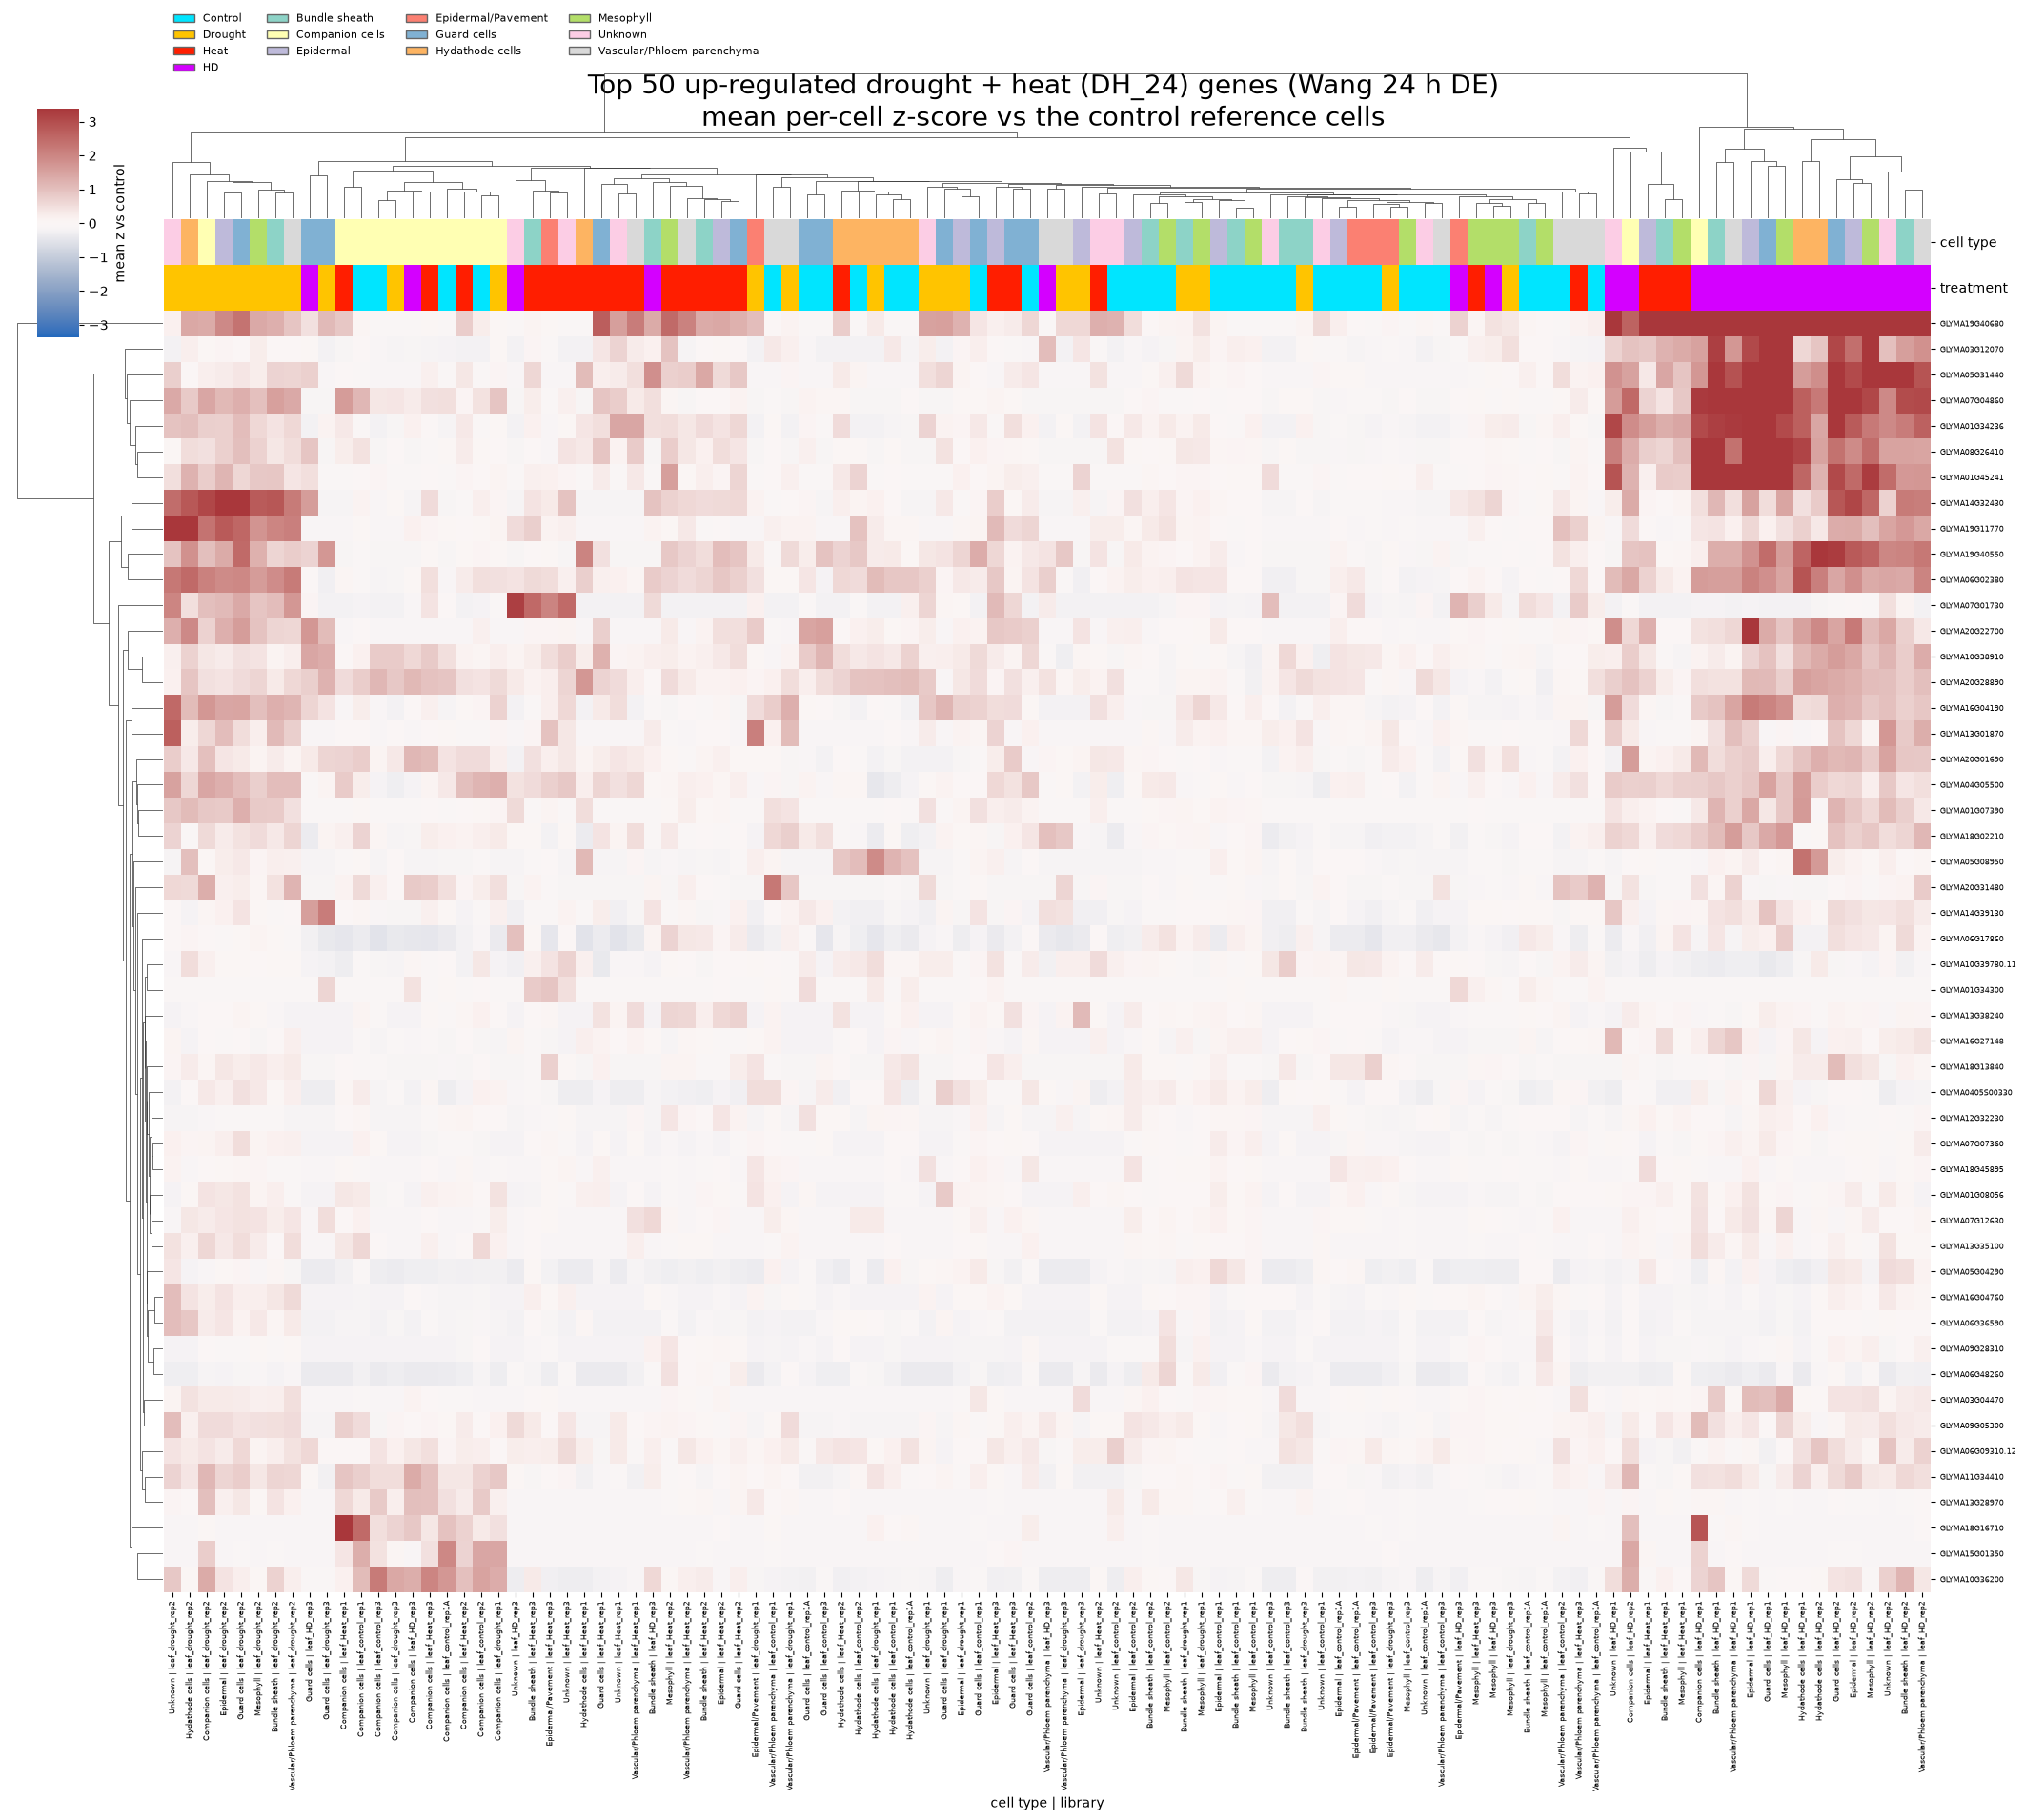

In [28]:
# --- drought + heat (DH_24) ---------------------------------------------------
drought_heat_de_genes = pd.read_csv(
    r"C:\Users\mikep\git\Soybean_Single_Cell_drought_heat\Referenced_data\Wang_DE_gene_lists\drough_heat_24h_DE.csv"
)

drought_heat_top_genes = select_top_up_genes(drought_heat_de_genes)
drought_heat_zscore_columns, _ = add_module_zscores(
    drought_heat_top_genes, "drought_heat"
)
_ = plot_module_clustermap(
    drought_heat_top_genes, drought_heat_zscore_columns, "drought + heat (DH_24)"
)

up-regulated DE genes present in the anndata: 510
150 of those are detected in >= 1% of the reference cells; keeping the top 50 by log2Ratio
added 50 z-score columns + heat_up50_zscore
kept 103 of 112 cell type x library groups (>= 10 cells)


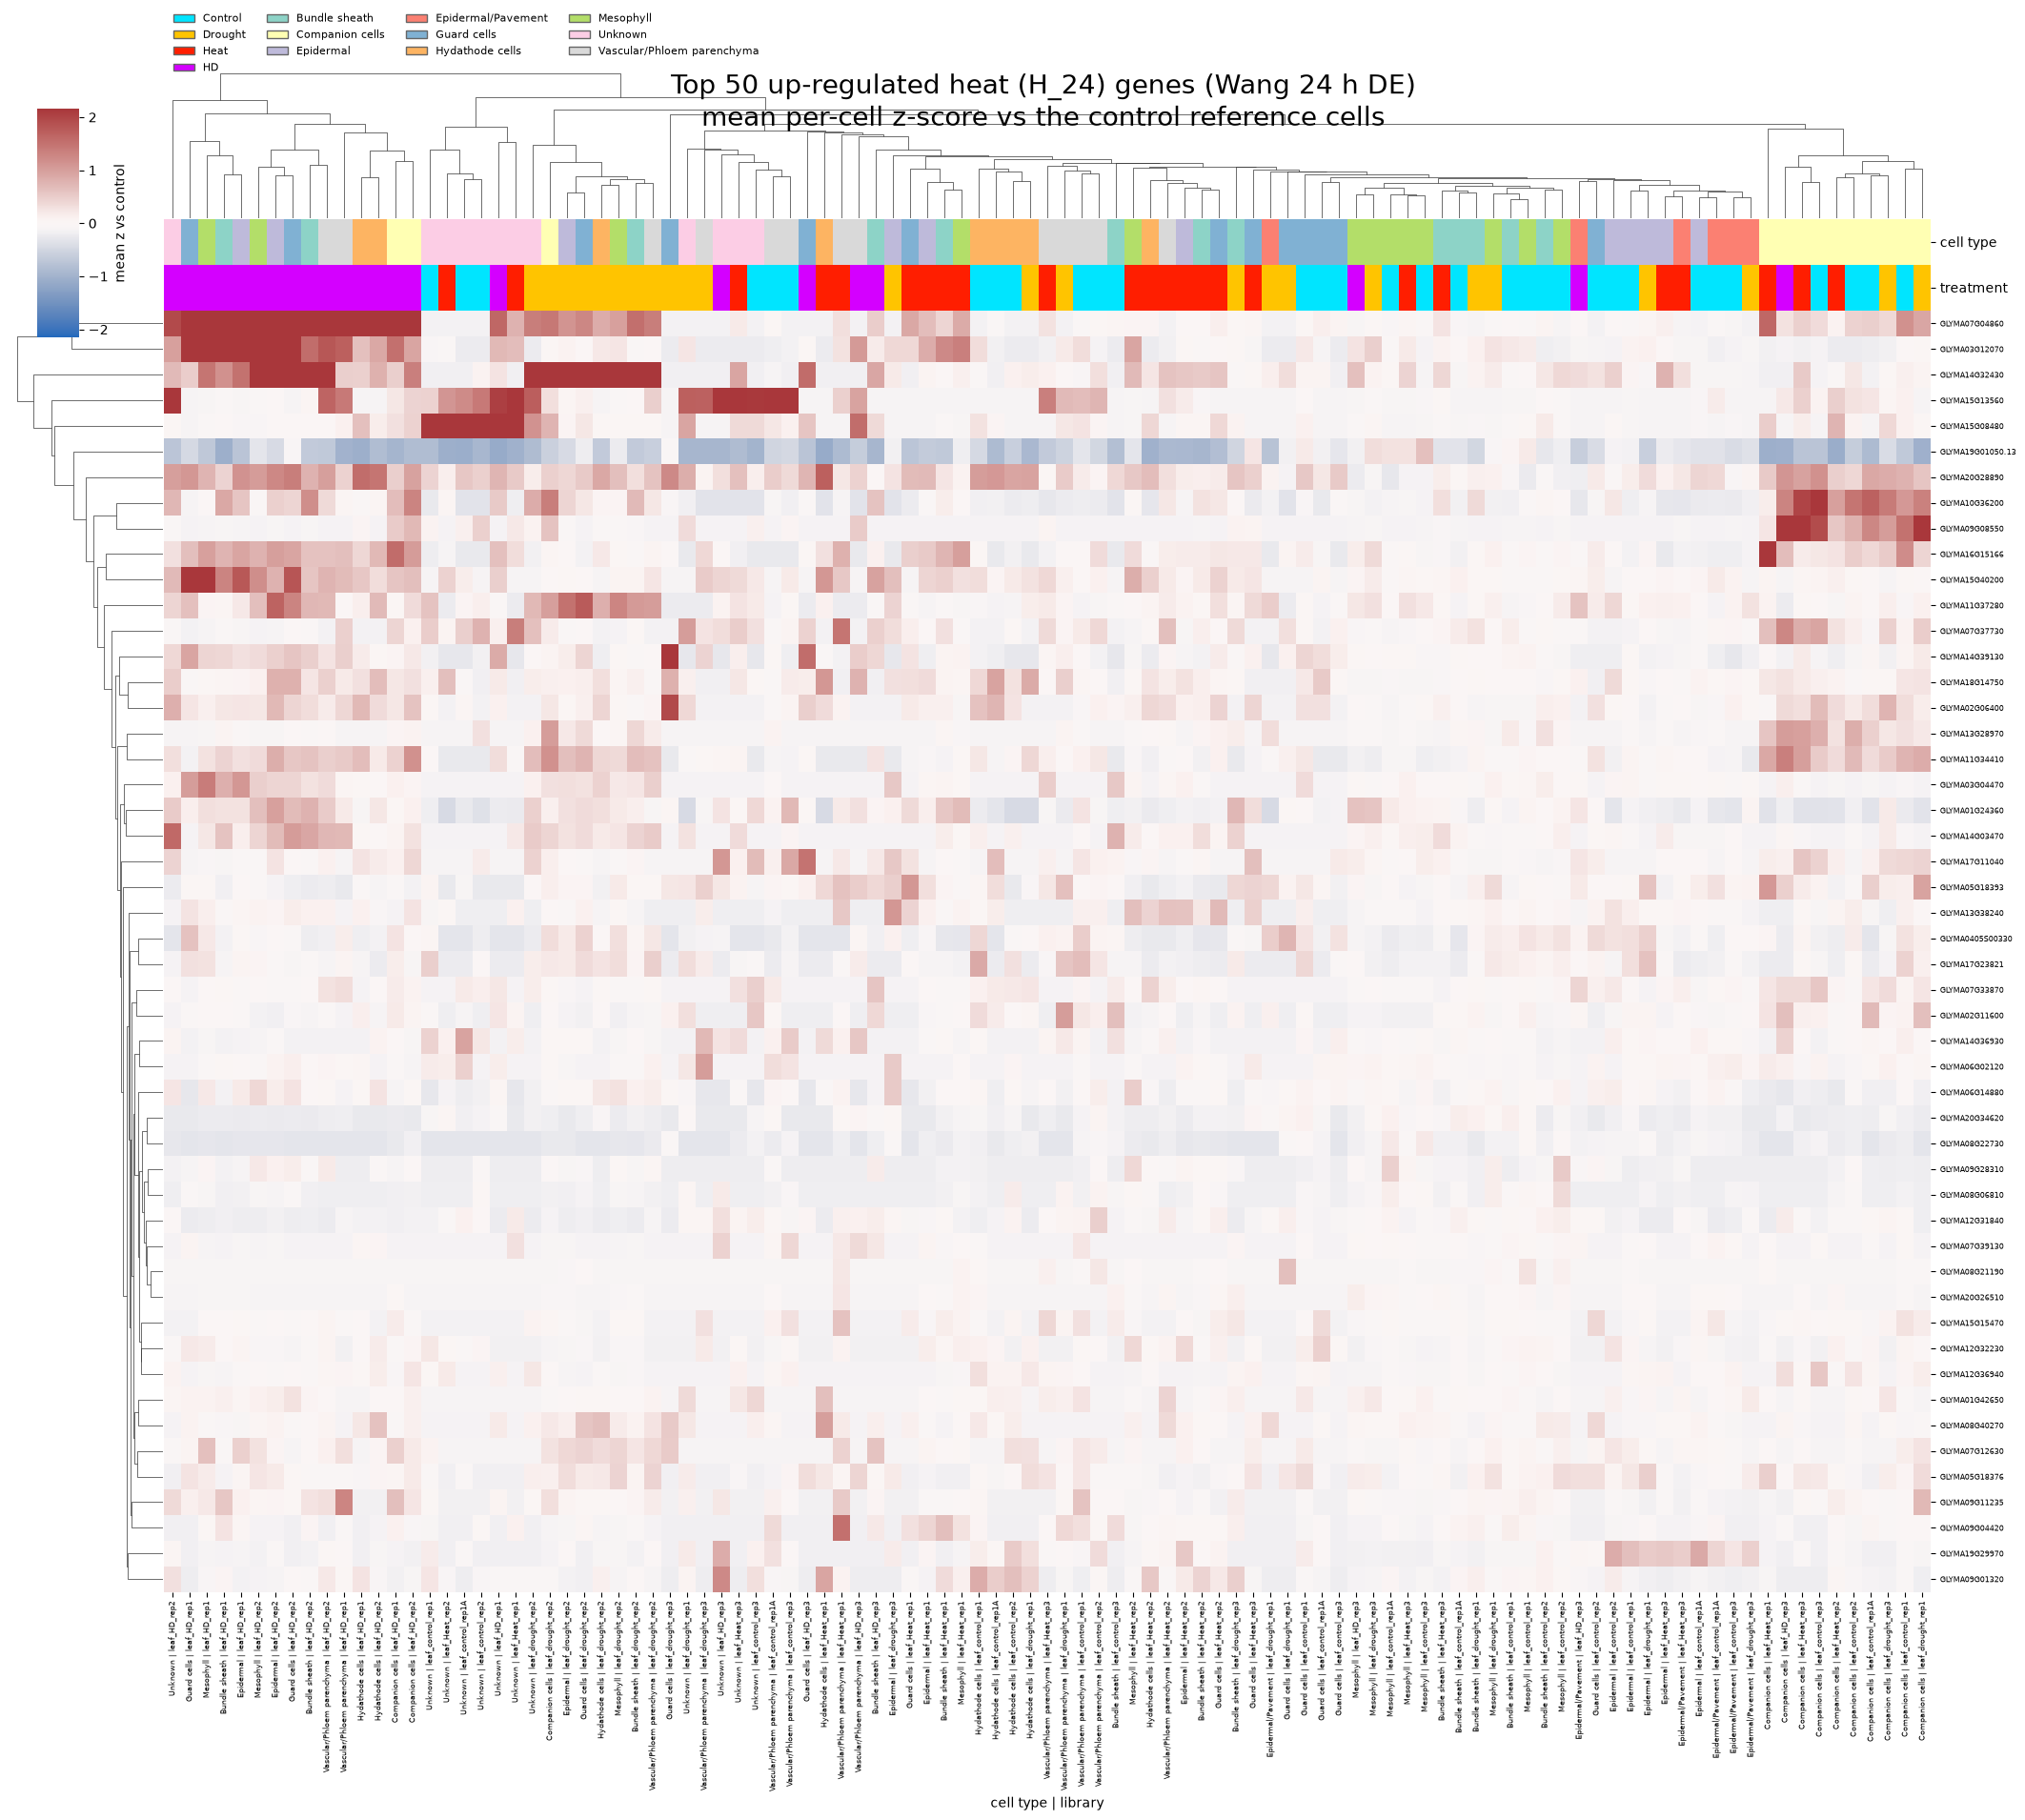

In [29]:
# --- heat only (H_24) ---------------------------------------------------------
heat_de_genes = pd.read_csv(
    r"C:\Users\mikep\git\Soybean_Single_Cell_drought_heat\Referenced_data\Wang_DE_gene_lists\heat_24h_DE.csv"
)

# NOTE: only 40 of this list's up genes clear the 5% detection floor, so this heatmap
# has 40 rows rather than 100. Pass e.g. min_detect_frac=0.01 to get closer to 100,
# at the cost of comparability with the two figures above.
heat_top_genes = select_top_up_genes(heat_de_genes)
heat_zscore_columns, _ = add_module_zscores(heat_top_genes, "heat")
_ = plot_module_clustermap(heat_top_genes, heat_zscore_columns, "heat (H_24)")